# Rolling ETAS vs FINE — per-window Bayona scores

Extension of the rolling comparison. Each rolling step is one forecast of length `HORIZON_DAYS` (1 day here: Hauksson pre-Ridgecrest, seeds 0 and 1). The intensity grids and Bayona scores are computed by `runnable_code/cache_rolling_analysis.py` and stored under the horizon directory in `analysis_cache/`. This notebook always runs that script; a repeat run only recomputes realizations that are new or whose files changed. Seed 2 on this horizon is unfinished and is left out.

The same cache is what a later notebook should load when comparing experiments:

```python
import etas.rolling_analysis as rolling_analysis
store = rolling_analysis.load_analysis(horizon_dir)
```

Shell, from the repository root:

```bash
python runnable_code/cache_rolling_analysis.py \
  --output-root outputs/rolling_continuation_hauksson_pre_ridgecrest_short \
  --config config/rolling_continuation_hauksson_pre_ridgecrest_short.json \
  --horizon-days 1 --dh 0.1 --num-simulations 200
```

The sections below also include the rolling-comparison figures (count error, cumulative counts, rates, interevent times, magnitudes, and the concatenated CSEP overlays) and a separate map for each rate: observed, ETAS mean, one ETAS realization, FINE mean, and one FINE realization.


In [28]:
%matplotlib inline
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "run_rolling_continuation.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "run_rolling_continuation.py").is_file():
                REPO_ROOT = parent
                break

for folder in (REPO_ROOT, REPO_ROOT / "runnable_code"):
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))

import continuation_ensemble as ceba
import etas.bayona_evaluations as bayona_evaluations
import etas.csep_utils as csep_utils

METHOD_LABELS = dict(ceba.DEFAULT_METHOD_LABELS)
METHOD_COLORS = dict(ceba.DEFAULT_METHOD_COLORS)
FORECAST_CATALOG_NAME = ceba._FORECAST_CATALOG_NAME

# ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_anss_comcat_bayona"
# ROLLING_CONFIG_PATH = REPO_ROOT / "config/rolling_continuation_anss_comcat_bayona.json"
# Hauksson pre-Ridgecrest short walk, 1-day horizon. Finished seeds are 0 and 1.
ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest_short"
ROLLING_CONFIG_PATH = REPO_ROOT / "config/rolling_continuation_hauksson_pre_ridgecrest_short.json"
HORIZON_DAYS = 1
METHODS = ["etas", "FINE"]
CSEP_DH = 0.1
BAYONA_N_SIM = 200
# Spatial maps: which seed to show (None → first seed).
SPATIAL_MAP_SEED: int | None = None


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


def discover_step_dirs(horizon_dir: Path) -> list[tuple[int, Path]]:
    steps = []
    for path in horizon_dir.iterdir():
        if path.is_dir() and path.name.startswith("step_"):
            steps.append((int(path.name.split("_")[1]), path))
    return sorted(steps, key=lambda item: item[0])


def load_step_windows(step_dir: Path) -> dict[str, Any] | None:
    summary_path = step_dir / "step_summary.json"
    if summary_path.is_file():
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        if isinstance(summary, dict) and "windows" in summary:
            return summary["windows"]
    config_path = step_dir / "step_config.json"
    if not config_path.is_file():
        return None
    cfg = json.loads(config_path.read_text(encoding="utf-8"))
    return {
        "forecast_start": cfg.get("timewindow_end"),
        "forecast_end": cfg.get("testwindow_end"),
    }


def method_dir(step_dir: Path, method: str) -> Path:
    candidate = step_dir / method
    if not candidate.is_dir() and method == ce.METHOD_FINE:
        candidate = step_dir / ce.METHOD_FINE_LEGACY
    return candidate


def load_step_forecast_catalog(step_dir: Path, method: str, seed: int) -> pd.DataFrame | None:
    folder = method_dir(step_dir, method)
    inv_dirs = sorted(folder.glob("inv_*")) if folder.is_dir() else []
    pointer = step_dir / "active_inversion.json"
    if pointer.is_file() and folder.is_dir():
        active_id = json.loads(pointer.read_text(encoding="utf-8")).get("inv_id")
        preferred = folder / f"inv_{active_id}"
        if active_id and preferred.is_dir():
            inv_dirs = [preferred]
    if not inv_dirs:
        return None
    catalog_path = inv_dirs[0] / f"seed_{seed}" / FORECAST_CATALOG_NAME
    if not catalog_path.is_file():
        return None
    return pd.read_csv(catalog_path)


def seeds_for_method(step_dir: Path, method: str) -> set[int]:
    folder = method_dir(step_dir, method)
    if not folder.is_dir():
        return set()
    return {
        int(path.parent.name.split("_")[1])
        for path in folder.glob("inv_*/seed_*/" + FORECAST_CATALOG_NAME)
    }


display(Markdown(
    f"**Horizon:** T = {HORIZON_DAYS:g} days. "
    f"Binary spatial simulations per window: {BAYONA_N_SIM}."
))


**Horizon:** T = 1 days. Binary spatial simulations per window: 200.

## Cached intensity and scores

The next cell runs the cache script, then loads it. Scores and rate maps come from that cache, not from a fresh integral over every seed.


In [29]:
import subprocess

import etas.rolling_analysis as rolling_analysis

script = REPO_ROOT / "runnable_code" / "cache_rolling_analysis.py"
command = [
    sys.executable,
    str(script),
    "--output-root", str(ROLLING_OUTPUT_ROOT),
    "--config", str(ROLLING_CONFIG_PATH),
    "--horizon-days", str(HORIZON_DAYS),
    "--dh", str(CSEP_DH),
    "--num-simulations", str(BAYONA_N_SIM),
    "--methods", *METHODS,
    "--repo-root", str(REPO_ROOT),
]
process = subprocess.Popen(
    command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
)
assert process.stdout is not None
for line in process.stdout:
    print(line, end="", flush=True)
return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"cache script exited {return_code}")

horizon_dir = rolling_analysis.horizon_directory(ROLLING_OUTPUT_ROOT, HORIZON_DAYS)
store = rolling_analysis.load_analysis(horizon_dir)
horizon_scores = store.scores
SEEDS = store.seeds
MAP_SEED = SPATIAL_MAP_SEED if SPATIAL_MAP_SEED in SEEDS else SEEDS[0]
display(Markdown(
    f"**{store.manifest['n_steps']}** horizon windows, **{len(SEEDS)}** seeds, "
    f"{store.manifest['n_cells']} spatial cells. Map seed **{MAP_SEED}**. "
    f"Cache: `{store.cache_dir}`."
))


cache up to date: 1134 steps, 2 seeds
window tests cached: 1134 steps, 2 methods, 200 binary likelihood simulations


**1134** horizon windows, **2** seeds, 5881 spatial cells. Map seed **0**. Cache: `/home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest_short/horizon_1d/analysis_cache`.

## Scores for each horizon window

Observed earthquakes are those inside the same step. ζ is the binary spatial quantile. Information gain is FINE against ETAS. These rows were written by the cache script.


In [30]:
display(horizon_scores.groupby("method")[["n_forecast", "n_observed", "zeta"]].mean())


,n_forecast,n_observed,zeta
method,,,
FINE,3.122700,0.959436,0.150099
etas,0.727816,0.959436,0.385469


## Figures

Counts use the horizon window as the time unit. The ζ diagram collects one binary spatial quantile from each window. The information-gain curve adds the per-window IGPA of FINE against ETAS. Cumulative counts are drawn when successive windows meet without overlapping.


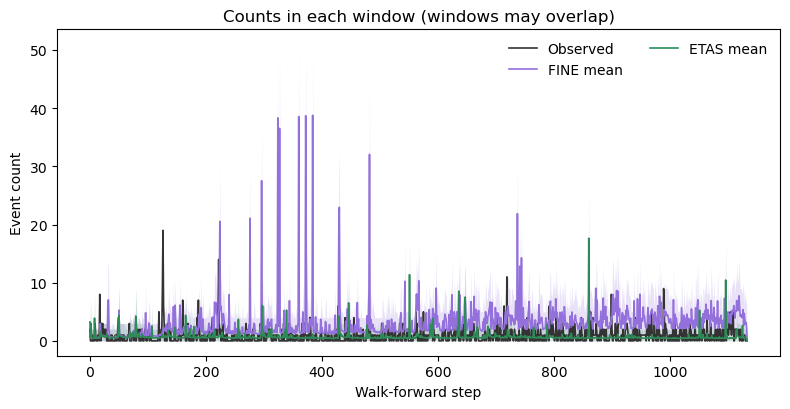

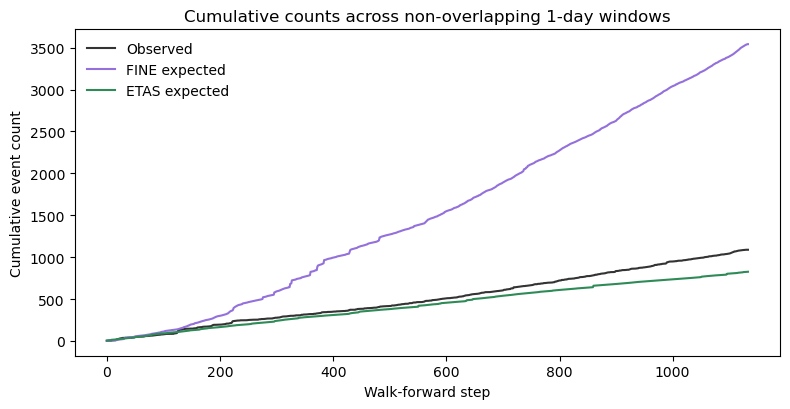

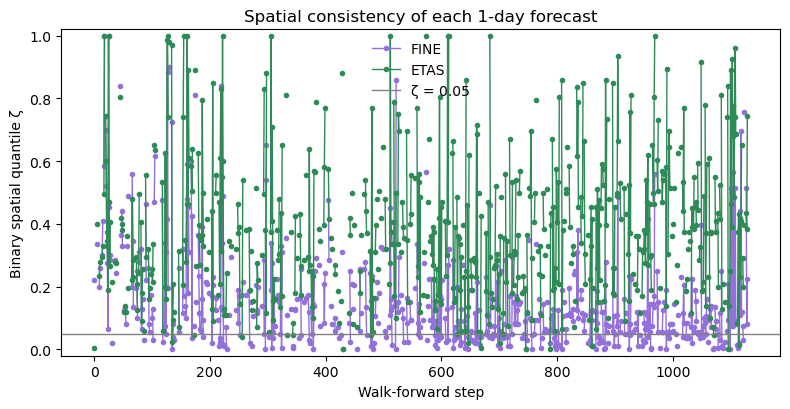

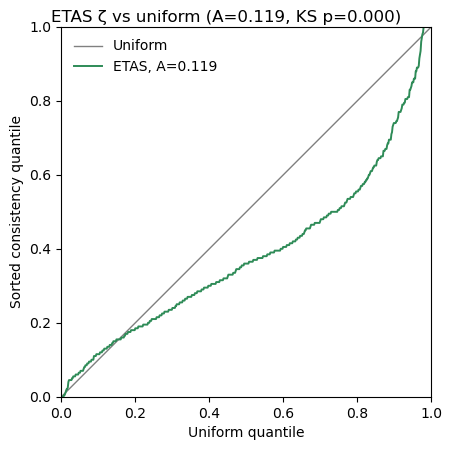

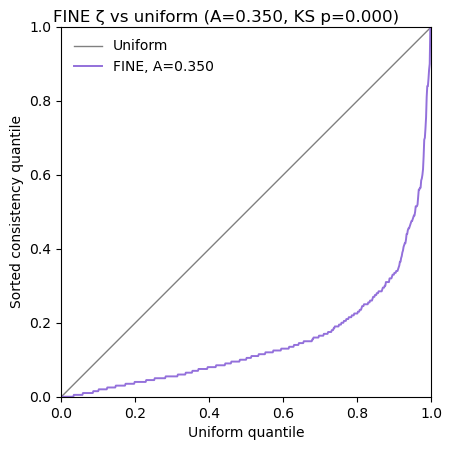

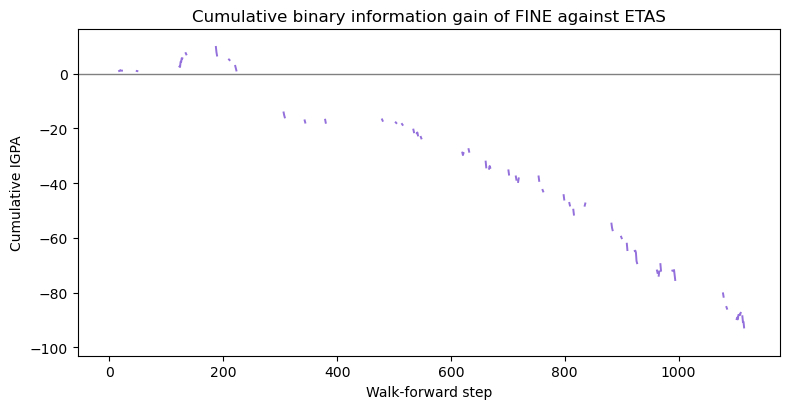

In [31]:
count_frame = horizon_scores[
    ["step_index", "method", "n_forecast", "n_observed", "poisson_low", "poisson_high"]
].copy()
show_fig(bayona_evaluations.plot_walkforward_counts(
    count_frame, colors=METHOD_COLORS, labels=METHOD_LABELS,
))

ordered = horizon_scores.sort_values(["step_index", "method"])
unique_steps = ordered.drop_duplicates("step_index").sort_values("step_index")
if len(unique_steps) >= 2:
    abut = (
        unique_steps["forecast_start"].iloc[1:].reset_index(drop=True)
        - unique_steps["forecast_end"].iloc[:-1].reset_index(drop=True)
    ).abs()
    windows_tile = bool((abut < pd.Timedelta("1min")).all())
else:
    windows_tile = True

if windows_tile:
    fig, ax = plt.subplots(figsize=(8.0, 4.2))
    ax.plot(
        unique_steps["step_index"], unique_steps["n_observed"].cumsum(),
        color="0.2", label="Observed",
    )
    for method, group in ordered.groupby("method", sort=False):
        group = group.sort_values("step_index")
        ax.plot(
            group["step_index"], group["n_forecast"].cumsum(),
            color=METHOD_COLORS.get(method),
            label=f"{METHOD_LABELS.get(method, method)} expected",
        )
    ax.set_xlabel("Walk-forward step")
    ax.set_ylabel("Cumulative event count")
    ax.set_title(f"Cumulative counts across non-overlapping {HORIZON_DAYS:g}-day windows")
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)
else:
    display(Markdown("_Windows overlap or leave a gap, so counts are not stacked._"))

fig, ax = plt.subplots(figsize=(8.0, 4.2))
for method, group in ordered.groupby("method", sort=False):
    group = group.sort_values("step_index")
    ax.plot(
        group["step_index"], group["zeta"],
        color=METHOD_COLORS.get(method), marker="o", ms=3, lw=1.0,
        label=METHOD_LABELS.get(method, method),
    )
ax.axhline(0.05, color="0.5", lw=1.0, label="ζ = 0.05")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Walk-forward step")
ax.set_ylabel("Binary spatial quantile ζ")
ax.set_title(f"Spatial consistency of each {HORIZON_DAYS:g}-day forecast")
ax.legend(frameon=False)
fig.tight_layout()
show_fig(fig)

for method in METHODS:
    zeta = ordered.loc[ordered["method"] == method, "zeta"].to_numpy(dtype=float)
    zeta = zeta[np.isfinite(zeta)]
    if zeta.size < 2:
        display(Markdown(
            f"_{METHOD_LABELS.get(method, method)} has fewer than two finite ζ values._"
        ))
        continue
    calibration_fig, summary = bayona_evaluations.plot_quantile_calibration(
        zeta, label=METHOD_LABELS.get(method, method), color=METHOD_COLORS.get(method),
    )
    calibration_fig.suptitle(
        f"{METHOD_LABELS.get(method, method)} ζ vs uniform "
        f"(A={summary['area']:.3f}, KS p={summary['ks_pvalue']:.3f})"
    )
    show_fig(calibration_fig)

fine = ordered.loc[ordered["method"] == "FINE"].sort_values("step_index")
if "IGPA" in fine.columns and fine["IGPA"].notna().any():
    fig, ax = plt.subplots(figsize=(8.0, 4.2))
    ax.plot(fine["step_index"], fine["IGPA"].cumsum(), color=METHOD_COLORS.get("FINE"), lw=1.4)
    ax.axhline(0.0, color="0.5", lw=1.0)
    ax.set_xlabel("Walk-forward step")
    ax.set_ylabel("Cumulative IGPA")
    ax.set_title("Cumulative binary information gain of FINE against ETAS")
    fig.tight_layout()
    show_fig(fig)
else:
    display(Markdown("_No finite information-gain values._"))


## Cumulative number test and window counts

Fig. 3c is one row per model for the whole test. The circle is the total observed count, colored by the percentage discrepancy. The black point is the total expected count from the intensity. The solid bar is the Poisson 95% interval of that total. The dashed bar is the negative-binomial 95% interval, using the same total as its mean and the variance of the saved catalog sizes.

The window-count figure is the Fig. 4 comparison over every forecast window in the test, rather than a daily count inside a chosen sequence. Circles are the observed count in that window. The bands are each model's Poisson 95% interval. A darker circle means more of the models cover that count.


,label,n_forecast,n_observed,delta_percent,poisson_low,poisson_high,nbd_low,nbd_high,catalog_variance
0,ETAS,825.343113,1088.0,24.141258,770.0,882.0,761.0,891.0,1104.5
1,FINE,3541.141915,1088.0,69.275448,3425.0,3658.0,74.0,13382.0,13261250.0


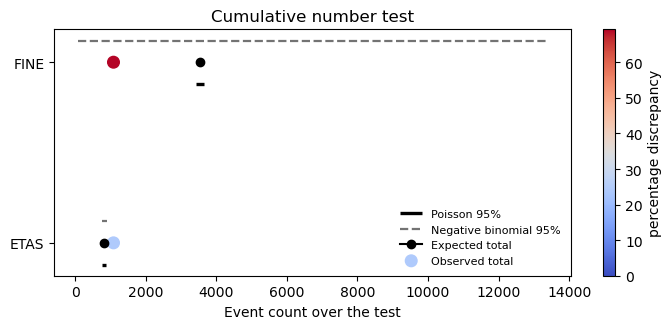

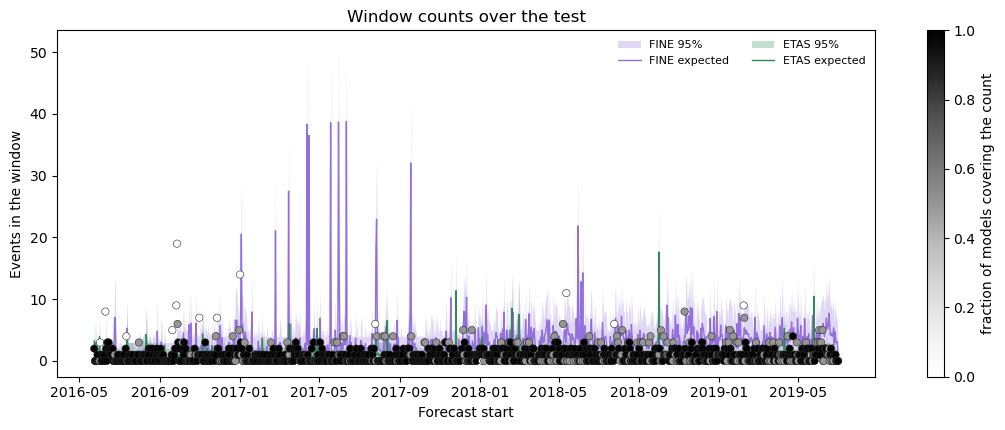

In [32]:
observed_total = float(
    horizon_scores.drop_duplicates("step_index")["n_observed"].sum()
)
cumulative_rows = []
for method in METHODS:
    group = horizon_scores.loc[horizon_scores["method"] == method]
    n_forecast = float(group["n_forecast"].sum())
    catalog_sizes = np.array([
        len(store.event_frame(method, seed)) for seed in SEEDS
    ], dtype=float)
    variance = float(np.var(catalog_sizes, ddof=1))
    poisson_low, poisson_high = bayona_evaluations.fmd_poisson_intervals(
        np.array([n_forecast]),
    )
    nbd = bayona_evaluations.negative_binomial_interval(n_forecast, variance)
    cumulative_rows.append({
        "label": METHOD_LABELS.get(method, method),
        "n_forecast": n_forecast,
        "n_observed": observed_total,
        "delta_percent": bayona_evaluations.count_discrepancy(n_forecast, observed_total),
        "poisson_low": float(poisson_low[0]),
        "poisson_high": float(poisson_high[0]),
        "nbd_low": np.nan if nbd is None else nbd[0],
        "nbd_high": np.nan if nbd is None else nbd[1],
        "catalog_variance": variance,
    })
cumulative_number = pd.DataFrame(cumulative_rows)
display(cumulative_number)
show_fig(bayona_evaluations.plot_cumulative_number_intervals(cumulative_number))

window_counts = horizon_scores[
    ["step_index", "forecast_start", "method", "n_forecast", "n_observed", "poisson_low", "poisson_high"]
].copy()
window_counts["forecast_start"] = pd.to_datetime(window_counts["forecast_start"])
show_fig(bayona_evaluations.plot_window_count_coverage(
    window_counts, colors=METHOD_COLORS, labels=METHOD_LABELS,
))


## Negative-binomial number test and binary conditional likelihood

One row per method per window, from the cached intensity. The number test is PyCSEP `negative_binomial_number_test`: `delta1` is the probability of at least the observed count and `delta2` is the probability of at most that count. The variance is the spread of the saved catalog sizes in that window. A window is inside the 95% test when both tails are at least 0.025. Windows whose catalogs are not overdispersed have no negative-binomial result.

The binary conditional likelihood test is PyCSEP `binary_conditional_likelihood_test` on that window's space–magnitude rate grid. The plotted value is the quantile of the observed binary log-likelihood among the simulated catalogs. Both tests are written by `cache_rolling_analysis.py` / `update_cache` into `analysis_cache/window_tests.csv`. This cell only loads that file (or fills it if intensity changed since the last cache run).


window tests cached: 1134 steps, 2 methods, 200 binary likelihood simulations


,n_windows,nbd_scored,nbd_consistent,binary_cl_consistent
method,,,,
FINE,1134,991,969,963
etas,1134,419,404,1085


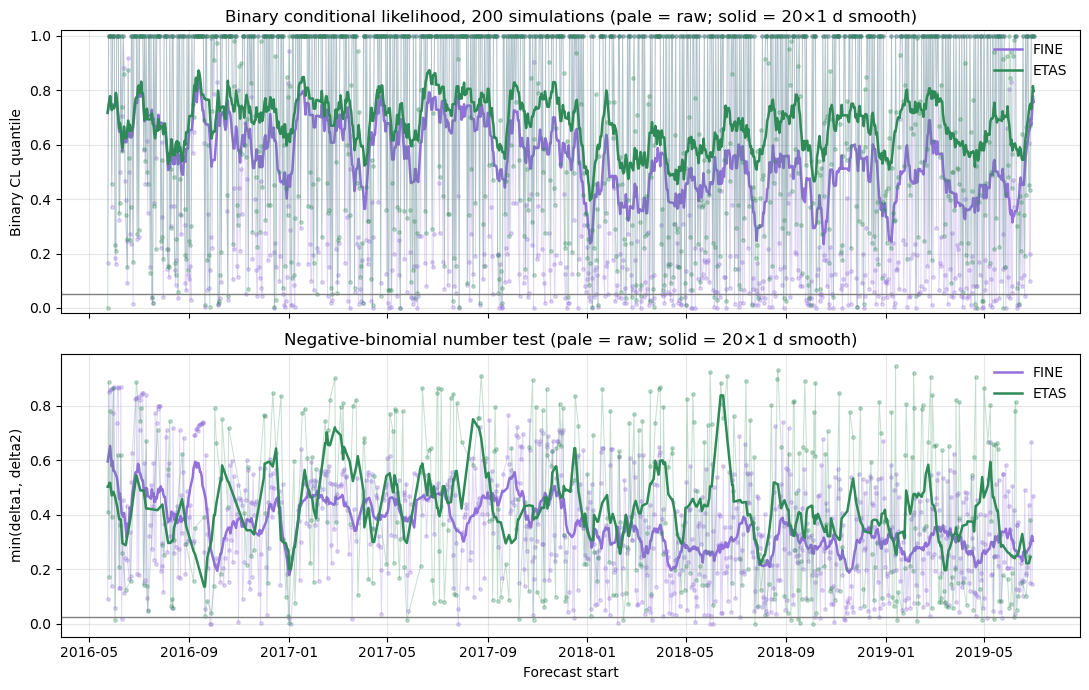

In [33]:
window_tests = rolling_analysis.window_distribution_tests(
    store, num_simulations=BAYONA_N_SIM, progress=print,
)
window_tests["nbd_consistent_95"] = (
    (window_tests["nbd_delta1"] >= 0.025) & (window_tests["nbd_delta2"] >= 0.025)
)
window_tests["binary_cl_consistent_95"] = window_tests["binary_cl_quantile"] >= 0.05
summary = window_tests.groupby("method").agg(
    n_windows=("step_index", "size"),
    nbd_scored=("nbd_delta1", "count"),
    nbd_consistent=("nbd_consistent_95", "sum"),
    binary_cl_consistent=("binary_cl_consistent_95", "sum"),
)
display(summary)

# Rolling mean over an O(1)×horizon window (centered; ~5 adjacent walk steps).
smooth_horizons = 20
smooth_window = pd.Timedelta(days=float(smooth_horizons * HORIZON_DAYS))
raw_alpha = 0.28


def _smooth_series(times: pd.Series, values: np.ndarray) -> pd.Series:
    series = pd.Series(values, index=pd.to_datetime(times)).sort_index()
    return series.rolling(smooth_window, center=True, min_periods=1).mean()


fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for method, group in window_tests.groupby("method", sort=False):
    group = group.sort_values("forecast_start")
    color = METHOD_COLORS.get(method)
    label = METHOD_LABELS.get(method, method)
    axes[0].plot(
        group["forecast_start"], group["binary_cl_quantile"],
        color=color, marker="o", ms=2.5, lw=0.7, alpha=raw_alpha,
    )
    binary_smooth = _smooth_series(group["forecast_start"], group["binary_cl_quantile"].to_numpy(dtype=float))
    axes[0].plot(
        binary_smooth.index, binary_smooth.to_numpy(),
        color=color, lw=1.8, label=label,
    )
    scored = group.loc[group["nbd_status"] == "normal"]
    nbd_y = np.minimum(scored["nbd_delta1"], scored["nbd_delta2"]).to_numpy(dtype=float)
    axes[1].plot(
        scored["forecast_start"], nbd_y,
        color=color, marker="o", ms=2.5, lw=0.7, alpha=raw_alpha,
    )
    if scored.shape[0]:
        nbd_smooth = _smooth_series(scored["forecast_start"], nbd_y)
        axes[1].plot(
            nbd_smooth.index, nbd_smooth.to_numpy(),
            color=color, lw=1.8, label=label,
        )
axes[0].axhline(0.05, color="0.5", lw=1.0)
axes[0].set_ylim(-0.02, 1.02)
axes[0].set_ylabel("Binary CL quantile")
axes[0].set_title(
    f"Binary conditional likelihood, {BAYONA_N_SIM} simulations "
    f"(pale = raw; solid = {smooth_horizons:g}×{HORIZON_DAYS:g} d smooth)"
)
axes[0].legend(frameon=False)
axes[0].grid(True, alpha=0.3)
axes[1].axhline(0.025, color="0.5", lw=1.0)
axes[1].set_ylabel("min(delta1, delta2)")
axes[1].set_xlabel("Forecast start")
axes[1].set_title(
    f"Negative-binomial number test "
    f"(pale = raw; solid = {smooth_horizons:g}×{HORIZON_DAYS:g} d smooth)"
)
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
show_fig(fig)




## Walk-forward path

Same two panels as the main rolling notebook. Count error is the mean catalog size minus the observed count, divided by the observed count. The magnitude panel is the Wasserstein distance between the forecast magnitudes and the earthquakes in that window.


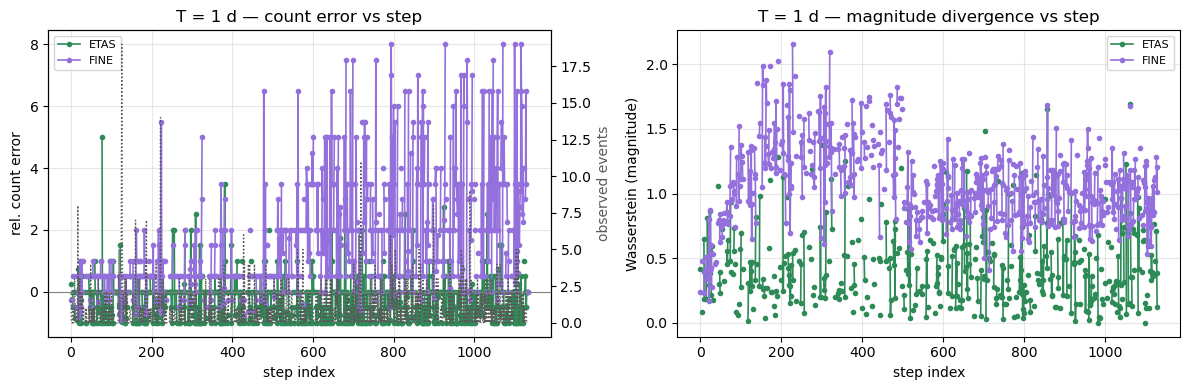

In [34]:
import etas.utility_functions as utility_functions
from scipy import stats as scipy_stats

cfg = json.loads(ROLLING_CONFIG_PATH.read_text(encoding="utf-8"))
origin = pd.to_datetime(cfg["timewindow_end"])
origin_days = float((origin - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"))
windows = store.windows()
observed = store.observed_frame()
observed_days = observed["time_days"].to_numpy(dtype=float) - origin_days
seed_frames = {
    method: {seed: store.event_frame(method, seed) for seed in SEEDS}
    for method in METHODS
}

path_rows = []
for window in windows.itertuples(index=False):
    start_days = float((window.forecast_start - origin) / pd.Timedelta("1D"))
    end_days = float((window.forecast_end - origin) / pd.Timedelta("1D"))
    obs_mag = observed.loc[
        (observed_days > start_days) & (observed_days <= end_days), "magnitude"
    ].to_numpy(dtype=float)
    row = {
        "step_index": int(window.step_index),
        "observed_n_events": int(obs_mag.size),
    }
    for method in METHODS:
        counts = []
        magnitudes = []
        for frame in seed_frames[method].values():
            dt = frame["time_days"].to_numpy(dtype=float) - origin_days
            chosen = frame.loc[(dt > start_days) & (dt <= end_days), "magnitude"].to_numpy(dtype=float)
            counts.append(chosen.size)
            if chosen.size:
                magnitudes.append(chosen)
        mean_count = float(np.mean(counts)) if counts else 0.0
        n_obs = int(obs_mag.size)
        if n_obs > 0:
            row[f"{method}_rel_count_error"] = (mean_count - n_obs) / n_obs
        else:
            row[f"{method}_rel_count_error"] = 0.0 if mean_count == 0.0 else np.inf
        if n_obs > 0 and magnitudes:
            row[f"{method}_wasserstein_mag"] = float(scipy_stats.wasserstein_distance(
                np.concatenate(magnitudes), obs_mag,
            ))
        else:
            row[f"{method}_wasserstein_mag"] = np.nan
    path_rows.append(row)
path_metrics = pd.DataFrame(path_rows).sort_values("step_index")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = path_metrics["step_index"].to_numpy()
for method in METHODS:
    color = METHOD_COLORS.get(method)
    label = METHOD_LABELS.get(method, method)
    axes[0].plot(x, path_metrics[f"{method}_rel_count_error"], marker="o", ms=3, lw=1.2, label=label, color=color)
    axes[1].plot(x, path_metrics[f"{method}_wasserstein_mag"], marker="o", ms=3, lw=1.2, label=label, color=color)
ax0_t = axes[0].twinx()
ax0_t.plot(x, path_metrics["observed_n_events"], color="0.35", ls=":", lw=1.0)
ax0_t.set_ylabel("observed events", color="0.35")
axes[0].axhline(0, color="0.5", lw=0.8)
axes[0].set_xlabel("step index")
axes[0].set_ylabel("rel. count error")
axes[0].set_title(f"T = {HORIZON_DAYS:g} d — count error vs step")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("step index")
axes[1].set_ylabel("Wasserstein (magnitude)")
axes[1].set_title(f"T = {HORIZON_DAYS:g} d — magnitude divergence vs step")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
show_fig(fig)


## Concatenated forecast trajectory

Cumulative counts are an interactive Plotly figure: drag to zoom, double-click to reset. Training is the dashed line before day 0. The test catalog and each seed start again at zero on day 0. The 30-day rate panel underneath is static.


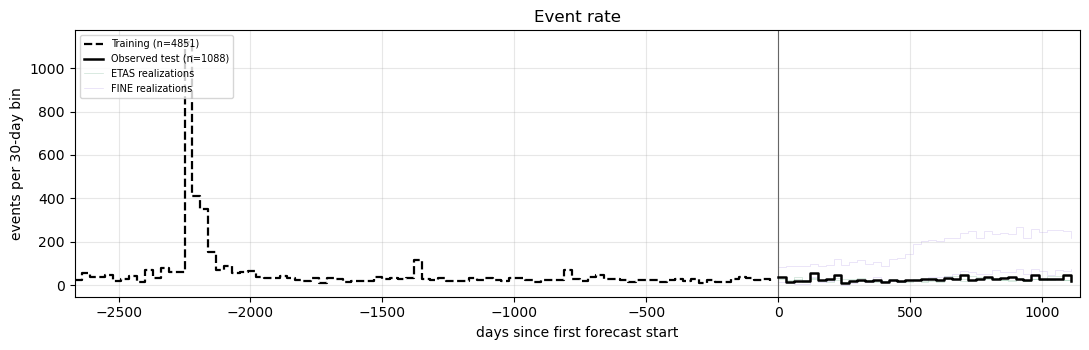

In [35]:
import plotly.graph_objects as go
from IPython.display import HTML

train = store.training_frame()
train_days = train["time_days"].to_numpy(dtype=float) - origin_days
forecast_end_days = float((windows["forecast_end"].max() - origin) / pd.Timedelta("1D"))
train_span = float(-np.min(train_days)) if train_days.size else 0.0
t_grid = np.linspace(-train_span, forecast_end_days, max(400, int(forecast_end_days) + 80))
forecast_mask = t_grid >= 0.0
train_mask = t_grid <= 0.0

negative_edges = -np.arange(0.0, train_span + 30.0, 30.0)[::-1]
negative_edges = negative_edges[negative_edges >= -train_span]
if negative_edges.size == 0 or negative_edges[0] > -train_span:
    negative_edges = np.insert(negative_edges, 0, -train_span)
positive_edges = np.arange(0.0, forecast_end_days + 30.0, 30.0)
if positive_edges.size == 0 or positive_edges[-1] < forecast_end_days:
    positive_edges = np.append(positive_edges, forecast_end_days)
bin_edges = np.unique(np.concatenate((negative_edges, positive_edges)))
pos = bin_edges[:-1] >= 0.0
neg = bin_edges[1:] <= 0.0


def _days(frame: pd.DataFrame) -> np.ndarray:
    return frame["time_days"].to_numpy(dtype=float) - origin_days


date_labels = (origin + pd.to_timedelta(t_grid, unit="D")).strftime("%Y-%m-%d %H:%M")
train_dates = date_labels[train_mask]
forecast_dates = date_labels[forecast_mask]
hover_coords = "t=%{x:.1f} d<br>date=%{customdata}<br>N=%{y:.0f}<extra></extra>"

fig_cum = go.Figure()
if train_days.size:
    train_curve = utility_functions.cumulative_on_grid(train_days, t_grid)
    fig_cum.add_trace(go.Scatter(
        x=t_grid[train_mask], y=train_curve[train_mask],
        mode="lines", name=f"Training (n={train_days.size})",
        line=dict(color="black", width=2, dash="dash"),
        customdata=train_dates,
        hovertemplate=f"Training<br>{hover_coords}",
    ))
if observed_days.size:
    obs_curve = utility_functions.cumulative_on_grid(observed_days, t_grid)
    fig_cum.add_trace(go.Scatter(
        x=t_grid[forecast_mask], y=obs_curve[forecast_mask],
        mode="lines", name=f"Observed test (n={observed_days.size})",
        line=dict(color="black", width=2.4),
        customdata=forecast_dates,
        hovertemplate=f"Observed test<br>{hover_coords}",
    ))

for method in METHODS:
    color = METHOD_COLORS.get(method, "gray")
    label = METHOD_LABELS.get(method, method)
    curves = [
        utility_functions.cumulative_on_grid(_days(frame), t_grid)
        for frame in seed_frames[method].values()
    ]
    stacked = np.vstack(curves)
    for index, (seed, curve) in enumerate(zip(SEEDS, stacked)):
        fig_cum.add_trace(go.Scatter(
            x=t_grid[forecast_mask], y=curve[forecast_mask],
            mode="lines",
            name=f"{label} realizations",
            legendgroup=f"{method}-real",
            showlegend=(index == 0),
            line=dict(color=color, width=0.8),
            opacity=0.45,
            customdata=forecast_dates,
            hovertemplate=f"{label} seed {seed}<br>{hover_coords}",
        ))
    fig_cum.add_trace(go.Scatter(
        x=t_grid[forecast_mask], y=np.mean(stacked, axis=0)[forecast_mask],
        mode="lines", name=f"{label} mean", legendgroup=method,
        line=dict(color=color, width=2.6),
        customdata=forecast_dates,
        hovertemplate=f"{label} mean<br>{hover_coords}",
    ))
    fig_cum.add_trace(go.Scatter(
        x=t_grid[forecast_mask], y=np.median(stacked, axis=0)[forecast_mask],
        mode="lines", name=f"{label} median", legendgroup=method,
        line=dict(color=color, width=2, dash="dot"),
        customdata=forecast_dates,
        hovertemplate=f"{label} median<br>{hover_coords}",
    ))

shapes = [dict(
    type="line", x0=0.0, x1=0.0, y0=0, y1=1, yref="paper",
    line=dict(color="gray", width=1, dash="dot"),
)]
for boundary in windows["forecast_start"].iloc[1:]:
    x_b = float((boundary - origin) / pd.Timedelta("1D"))
    shapes.append(dict(
        type="line", x0=x_b, x1=x_b, y0=0, y1=1, yref="paper",
        line=dict(color="rgba(160,160,160,0.45)", width=0.6),
    ))
fig_cum.update_layout(
    title=f"Cumulative event count — T = {HORIZON_DAYS:g} d walk-forward",
    xaxis_title="days since first forecast start",
    yaxis_title="cumulative number of events N(t)",
    height=520,
    template="plotly_white",
    legend=dict(x=0.01, y=0.99, xanchor="left", yanchor="top"),
    shapes=shapes,
    margin=dict(t=60),
)
fig_cum.update_xaxes(range=[-train_span, forecast_end_days * 1.01])
display(HTML(fig_cum.to_html(include_plotlyjs="cdn", full_html=False)))

fig_rate, ax_rate = plt.subplots(figsize=(11, 3.6))
if train_days.size:
    train_bins = utility_functions.events_per_time_bin(train_days, bin_edges)
    ax_rate.step(
        bin_edges[:-1][neg], train_bins[neg], where="post",
        color="black", lw=1.6, ls="--", label=f"Training (n={train_days.size})", zorder=3,
    )
if observed_days.size:
    obs_bins = utility_functions.events_per_time_bin(observed_days, bin_edges)
    ax_rate.step(
        bin_edges[:-1][pos], obs_bins[pos], where="post",
        color="black", lw=1.8, label=f"Observed test (n={observed_days.size})", zorder=4,
    )
for method in METHODS:
    color = METHOD_COLORS.get(method)
    label = METHOD_LABELS.get(method, method)
    for index, frame in enumerate(seed_frames[method].values()):
        counts = utility_functions.events_per_time_bin(_days(frame), bin_edges)
        ax_rate.step(
            bin_edges[:-1][pos], counts[pos], where="post",
            color=color, lw=0.5, alpha=0.25,
            label=f"{label} realizations" if index == 0 else None,
        )
ax_rate.axvline(0.0, color="0.4", lw=0.8)
ax_rate.set_xlim(-train_span, forecast_end_days * 1.01)
ax_rate.set_xlabel("days since first forecast start")
ax_rate.set_ylabel("events per 30-day bin")
ax_rate.set_title("Event rate")
ax_rate.legend(fontsize=7, loc="upper left")
ax_rate.grid(True, alpha=0.3)
fig_rate.tight_layout()
show_fig(fig_rate)


## Background probability μ / λ(t)

For each forecast event, the soft probability that it is background is the instantaneous background share of the ETAS intensity at its location and time: \(P_0 = \mu / \lambda(x,y,t)\), with \(\lambda\) built from the fitted parameters of that rolling window and the history available at the window start (observed catalog up to the forecast start), plus earlier simulated events in the same window. Pale lines are individual seeds; the solid line is the seed-mean step function on the common time grid (same visual language as the cumulative count figure). Observed test events use the same formula with observed-only history and are drawn in black. The next code cell plots only the observed series and each method's seed-mean, smoothed with a centered rolling window of `P0_SMOOTH_DAYS` (edit that constant and re-run that cell).


In [36]:
import etas.rate_simulation as rate_simulation
import etas.utility_functions as utility_functions

# --- helpers -----------------------------------------------------------------

def _params_from_fit(fit: dict) -> dict:
    params = utility_functions.expand_theta_log10(dict(fit["theta"]))
    params["m_c"] = float(fit["mc"])
    return params


def _instantaneous_rates(
    lat: np.ndarray,
    lon: np.ndarray,
    t_days: np.ndarray,
    hist_lat: np.ndarray,
    hist_lon: np.ndarray,
    hist_mag: np.ndarray,
    hist_t: np.ndarray,
    params: dict,
    *,
    batch_size: int = 64,
) -> np.ndarray:
    """ETAS intensity density λ(x, y, t) at each target event."""
    lat = np.asarray(lat, dtype=np.float64).ravel()
    lon = np.asarray(lon, dtype=np.float64).ravel()
    t_days = np.asarray(t_days, dtype=np.float64).ravel()
    n = lat.size
    rates = np.full(n, float(params["mu"]), dtype=np.float64)
    if n == 0 or hist_t.size == 0:
        return rates

    hlat = np.radians(np.asarray(hist_lat, dtype=np.float64).ravel())
    hlon = np.radians(np.asarray(hist_lon, dtype=np.float64).ravel())
    hm = np.asarray(hist_mag, dtype=np.float64).ravel()
    ht = np.asarray(hist_t, dtype=np.float64).ravel()
    tlat = np.radians(lat)
    tlon = np.radians(lon)

    k0 = float(params["k0"])
    a = float(params["a"])
    d = float(params["d"])
    gamma = float(params["gamma"])
    rho = float(params["rho"])
    c = float(params["c"])
    tau = float(params["tau"])
    omega = float(params["omega"])
    mc = float(params["m_c"])
    mu = float(params["mu"])
    mag_gap = hm - mc
    amplitude = k0 * np.exp(a * mag_gap)
    core = d * np.exp(gamma * mag_gap)

    for start in range(0, n, int(batch_size)):
        stop = min(start + int(batch_size), n)
        dt = t_days[start:stop, None] - ht[None, :]
        past = dt > 0.0
        if not np.any(past):
            rates[start:stop] = mu
            continue
        dist_sq = np.square(utility_functions.haversine_km(
            hlat[None, :], tlat[start:stop, None],
            hlon[None, :], tlon[start:stop, None],
        ))
        spatial = amplitude[None, :] / (dist_sq + core[None, :]) ** (1.0 + rho)
        g_vals = np.exp(-dt / tau) / (dt + c) ** (1.0 + omega)
        triggered = np.sum(np.where(past, spatial * g_vals, 0.0), axis=1)
        rates[start:stop] = mu + triggered
    return rates


def _background_probability(rates: np.ndarray, mu: float) -> np.ndarray:
    rates = np.asarray(rates, dtype=np.float64)
    out = np.full(rates.shape, np.nan, dtype=np.float64)
    ok = np.isfinite(rates) & (rates > 0.0)
    out[ok] = float(mu) / rates[ok]
    return np.clip(out, 0.0, 1.0)


def _step_on_grid(event_t: np.ndarray, event_p: np.ndarray, grid: np.ndarray) -> np.ndarray:
    """Forward-fill each event's P0 onto ``grid`` (NaN before the first event)."""
    out = np.full(grid.shape, np.nan, dtype=np.float64)
    if event_t.size == 0:
        return out
    order = np.argsort(event_t)
    event_t = event_t[order]
    event_p = event_p[order]
    idx = np.searchsorted(event_t, grid, side="right") - 1
    valid = idx >= 0
    out[valid] = event_p[idx[valid]]
    return out


def _window_fit_map(horizon_dir: Path) -> dict[int, dict]:
    """Map step_index → linearized ETAS params for that window."""
    out: dict[int, dict] = {}
    for step_index, step_dir in discover_step_dirs(horizon_dir):
        fit = rolling_analysis._theta_from_step_dir(step_dir)
        if fit is None:
            continue
        out[int(step_index)] = _params_from_fit(fit)
    return out


def _events_in_window(
    frame: pd.DataFrame,
    start_days: float,
    end_days: float,
    origin_days: float,
) -> pd.DataFrame:
    t = frame["time_days"].to_numpy(dtype=float) - origin_days
    chosen = frame.loc[(t > start_days) & (t <= end_days)].copy()
    chosen["t_rel"] = chosen["time_days"].to_numpy(dtype=float) - origin_days
    return chosen.sort_values("time_days")


# Observed history used as the base for every window (training + test).
observed_history = pd.concat(
    [store.training_frame(), store.observed_frame()],
    ignore_index=True,
).sort_values("time_days")
observed_history_t = observed_history["time_days"].to_numpy(dtype=float)
window_params = _window_fit_map(horizon_dir)
if not window_params:
    raise RuntimeError("No inversion parameters found under the horizon steps")

# Fallback params when a step is missing a fit file.
_default_params = next(iter(window_params.values()))


def _p0_for_frame(frame: pd.DataFrame, method_seeds: bool = True) -> tuple[np.ndarray, np.ndarray]:
    """Return (t_rel_days, P0) for every forecast event in ``frame`` across windows."""
    times: list[float] = []
    probs: list[float] = []
    for window in windows.itertuples(index=False):
        start_days = float((window.forecast_start - origin) / pd.Timedelta("1D"))
        end_days = float((window.forecast_end - origin) / pd.Timedelta("1D"))
        start_abs = float((window.forecast_start - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"))
        params = window_params.get(int(window.step_index), _default_params)
        mu = float(params["mu"])
        base = observed_history.loc[observed_history_t <= start_abs]
        hist_lat = base["latitude"].to_numpy(dtype=float)
        hist_lon = base["longitude"].to_numpy(dtype=float)
        hist_mag = base["magnitude"].to_numpy(dtype=float)
        hist_t = base["time_days"].to_numpy(dtype=float)
        chosen = _events_in_window(frame, start_days, end_days, origin_days)
        if chosen.empty:
            continue
        # Grow history with earlier events in this same window (cascading).
        for row in chosen.itertuples(index=False):
            rates = _instantaneous_rates(
                np.array([row.latitude]), np.array([row.longitude]), np.array([row.time_days]),
                hist_lat, hist_lon, hist_mag, hist_t, params,
            )
            times.append(float(row.t_rel))
            probs.append(float(_background_probability(rates, mu)[0]))
            hist_lat = np.append(hist_lat, row.latitude)
            hist_lon = np.append(hist_lon, row.longitude)
            hist_mag = np.append(hist_mag, row.magnitude)
            hist_t = np.append(hist_t, row.time_days)
    return np.asarray(times, dtype=float), np.asarray(probs, dtype=float)


# Observed test events (black reference).
obs_times: list[float] = []
obs_probs: list[float] = []
for window in windows.itertuples(index=False):
    start_days = float((window.forecast_start - origin) / pd.Timedelta("1D"))
    end_days = float((window.forecast_end - origin) / pd.Timedelta("1D"))
    start_abs = float((window.forecast_start - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"))
    params = window_params.get(int(window.step_index), _default_params)
    mu = float(params["mu"])
    base = observed_history.loc[observed_history_t <= start_abs]
    chosen = _events_in_window(observed, start_days, end_days, origin_days)
    if chosen.empty:
        continue
    hist_lat = base["latitude"].to_numpy(dtype=float)
    hist_lon = base["longitude"].to_numpy(dtype=float)
    hist_mag = base["magnitude"].to_numpy(dtype=float)
    hist_t = base["time_days"].to_numpy(dtype=float)
    for row in chosen.itertuples(index=False):
        rates = _instantaneous_rates(
            np.array([row.latitude]), np.array([row.longitude]), np.array([row.time_days]),
            hist_lat, hist_lon, hist_mag, hist_t, params,
        )
        obs_times.append(float(row.t_rel))
        obs_probs.append(float(_background_probability(rates, mu)[0]))
        hist_lat = np.append(hist_lat, row.latitude)
        hist_lon = np.append(hist_lon, row.longitude)
        hist_mag = np.append(hist_mag, row.magnitude)
        hist_t = np.append(hist_t, row.time_days)
obs_times_arr = np.asarray(obs_times, dtype=float)
obs_probs_arr = np.asarray(obs_probs, dtype=float)

p0_by_method: dict[str, dict[int, tuple[np.ndarray, np.ndarray]]] = {}
for method in METHODS:
    p0_by_method[method] = {}
    for seed in SEEDS:
        p0_by_method[method][seed] = _p0_for_frame(seed_frames[method][seed])

# Shared forecast time grid (reuse cumulative figure span).
t_grid_bg = t_grid[forecast_mask]
date_labels_bg = (origin + pd.to_timedelta(t_grid_bg, unit="D")).strftime("%Y-%m-%d %H:%M")
hover_bg = "t=%{x:.1f} d<br>date=%{customdata}<br>P0=%{y:.3f}<extra></extra>"

fig_bg = go.Figure()
if obs_times_arr.size:
    order = np.argsort(obs_times_arr)
    fig_bg.add_trace(go.Scatter(
        x=obs_times_arr[order], y=obs_probs_arr[order],
        mode="lines+markers",
        name=f"Observed test (n={obs_times_arr.size})",
        line=dict(color="black", width=2.4),
        marker=dict(size=4, color="black"),
        customdata=(origin + pd.to_timedelta(obs_times_arr[order], unit="D")).strftime("%Y-%m-%d %H:%M"),
        hovertemplate=f"Observed test<br>{hover_bg}",
    ))

mean_curves_bg: dict[str, np.ndarray] = {}
for method in METHODS:
    color = METHOD_COLORS.get(method, "gray")
    label = METHOD_LABELS.get(method, method)
    stepped = []
    for index, seed in enumerate(SEEDS):
        times_s, probs_s = p0_by_method[method][seed]
        if times_s.size == 0:
            stepped.append(np.full(t_grid_bg.shape, np.nan))
            continue
        order = np.argsort(times_s)
        times_s, probs_s = times_s[order], probs_s[order]
        fig_bg.add_trace(go.Scatter(
            x=times_s, y=probs_s,
            mode="lines+markers",
            name=f"{label} realizations",
            legendgroup=f"{method}-real-bg",
            showlegend=(index == 0),
            line=dict(color=color, width=0.8),
            marker=dict(size=3, color=color),
            opacity=0.45,
            customdata=(origin + pd.to_timedelta(times_s, unit="D")).strftime("%Y-%m-%d %H:%M"),
            hovertemplate=f"{label} seed {seed}<br>{hover_bg}",
        ))
        stepped.append(_step_on_grid(times_s, probs_s, t_grid_bg))
    stacked = np.vstack(stepped)
    with np.errstate(all="ignore"):
        mean_curve = np.nanmean(stacked, axis=0)
        median_curve = np.nanmedian(stacked, axis=0)
    mean_curves_bg[method] = mean_curve
    fig_bg.add_trace(go.Scatter(
        x=t_grid_bg, y=mean_curve,
        mode="lines", name=f"{label} mean", legendgroup=f"{method}-bg",
        line=dict(color=color, width=2.6),
        customdata=date_labels_bg,
        hovertemplate=f"{label} mean<br>{hover_bg}",
    ))
    fig_bg.add_trace(go.Scatter(
        x=t_grid_bg, y=median_curve,
        mode="lines", name=f"{label} median", legendgroup=f"{method}-bg",
        line=dict(color=color, width=2, dash="dot"),
        customdata=date_labels_bg,
        hovertemplate=f"{label} median<br>{hover_bg}",
    ))

shapes_bg = [dict(
    type="line", x0=0.0, x1=0.0, y0=0, y1=1, yref="paper",
    line=dict(color="gray", width=1, dash="dot"),
)]
for boundary in windows["forecast_start"].iloc[1:]:
    x_b = float((boundary - origin) / pd.Timedelta("1D"))
    shapes_bg.append(dict(
        type="line", x0=x_b, x1=x_b, y0=0, y1=1, yref="paper",
        line=dict(color="rgba(160,160,160,0.45)", width=0.6),
    ))
fig_bg.update_layout(
    title=f"Background probability μ/λ — T = {HORIZON_DAYS:g} d walk-forward",
    xaxis_title="days since first forecast start",
    yaxis_title="P(background) = μ / λ(x, y, t)",
    yaxis=dict(range=[-0.02, 1.05]),
    height=520,
    template="plotly_white",
    legend=dict(x=0.01, y=0.99, xanchor="left", yanchor="top"),
    shapes=shapes_bg,
    margin=dict(t=60),
)
fig_bg.update_xaxes(range=[0.0, forecast_end_days * 1.01])
display(HTML(fig_bg.to_html(include_plotlyjs="cdn", full_html=False)))

# Summary: mean P0 over events
summary_rows = []
if obs_probs_arr.size:
    summary_rows.append({
        "catalog": "observed",
        "n_events": int(obs_probs_arr.size),
        "mean_P0": float(np.mean(obs_probs_arr)),
        "median_P0": float(np.median(obs_probs_arr)),
    })
for method in METHODS:
    for seed in SEEDS:
        _t, _p = p0_by_method[method][seed]
        if _p.size == 0:
            continue
        summary_rows.append({
            "catalog": f"{METHOD_LABELS.get(method, method)} seed {seed}",
            "n_events": int(_p.size),
            "mean_P0": float(np.mean(_p)),
            "median_P0": float(np.median(_p)),
        })
display(pd.DataFrame(summary_rows))


,catalog,n_events,mean_P0,median_P0
0,observed,1088,0.147269,0.004893
1,ETAS seed 0,963,0.059779,0.000406
2,ETAS seed 1,1010,0.039366,0.000265
3,FINE seed 0,1491,0.002512,0.000517
4,FINE seed 1,6641,0.014253,0.000002


In [42]:
# Smoothed background probability (re-run after changing P0_SMOOTH_DAYS).
# Requires the previous cell: obs_times_arr, obs_probs_arr, mean_curves_bg,
# t_grid_bg, shapes_bg, forecast_end_days.
P0_SMOOTH_DAYS = int(HORIZON_DAYS*4)


def _smooth_p0_on_days(
    times_days: np.ndarray,
    values: np.ndarray,
    window_days: float,
) -> pd.Series:
    """Centered rolling mean over ``window_days`` calendar days."""
    times_days = np.asarray(times_days, dtype=float)
    values = np.asarray(values, dtype=float)
    ok = np.isfinite(times_days) & np.isfinite(values)
    if not np.any(ok):
        return pd.Series(dtype=float)
    stamps = origin + pd.to_timedelta(times_days[ok], unit="D")
    series = pd.Series(values[ok], index=pd.to_datetime(stamps)).sort_index()
    series = series[~series.index.duplicated(keep="last")]
    return series.rolling(
        pd.Timedelta(days=float(window_days)), center=True, min_periods=1,
    ).mean()


if "obs_times_arr" not in globals() or "mean_curves_bg" not in globals():
    raise RuntimeError("Run the previous background-probability cell first.")

_hover_smooth = (
    "t=%{x:.1f} d<br>date=%{customdata}<br>"
    f"P0=%{{y:.3f}} ({P0_SMOOTH_DAYS:g}-day smooth)<extra></extra>"
)
fig_bg_smooth = go.Figure()
if obs_times_arr.size:
    obs_smooth = _smooth_p0_on_days(obs_times_arr, obs_probs_arr, P0_SMOOTH_DAYS)
    if len(obs_smooth):
        obs_t = (obs_smooth.index - origin) / pd.Timedelta("1D")
        fig_bg_smooth.add_trace(go.Scatter(
            x=obs_t.to_numpy(dtype=float),
            y=obs_smooth.to_numpy(dtype=float),
            mode="lines",
            name=f"Observed ({P0_SMOOTH_DAYS:g}-day smooth)",
            line=dict(color="black", width=2.6),
            customdata=obs_smooth.index.strftime("%Y-%m-%d %H:%M"),
            hovertemplate="Observed<br>" + _hover_smooth,
        ))

for method in METHODS:
    color = METHOD_COLORS.get(method, "gray")
    label = METHOD_LABELS.get(method, method)
    mean_curve = mean_curves_bg.get(method)
    if mean_curve is None or not np.any(np.isfinite(mean_curve)):
        continue
    method_smooth = _smooth_p0_on_days(t_grid_bg, mean_curve, P0_SMOOTH_DAYS)
    if not len(method_smooth):
        continue
    method_t = (method_smooth.index - origin) / pd.Timedelta("1D")
    fig_bg_smooth.add_trace(go.Scatter(
        x=method_t.to_numpy(dtype=float),
        y=method_smooth.to_numpy(dtype=float),
        mode="lines",
        name=f"{label} mean ({P0_SMOOTH_DAYS:g}-day smooth)",
        line=dict(color=color, width=2.6),
        customdata=method_smooth.index.strftime("%Y-%m-%d %H:%M"),
        hovertemplate=f"{label} mean<br>" + _hover_smooth,
    ))

fig_bg_smooth.update_layout(
    title=(
        f"Background probability μ/λ — {P0_SMOOTH_DAYS:g}-day smooth "
        f"(T = {HORIZON_DAYS:g} d)"
    ),
    xaxis_title="days since first forecast start",
    yaxis_title=f"P(background), {P0_SMOOTH_DAYS:g}-day rolling mean",
    yaxis=dict(range=[-0.02, 1.05]),
    height=420,
    template="plotly_white",
    legend=dict(x=0.01, y=0.99, xanchor="left", yanchor="top"),
    shapes=shapes_bg,
    margin=dict(t=60),
)
fig_bg_smooth.update_xaxes(range=[0.0, forecast_end_days * 1.01])
# plotly.js already loaded by the previous cell's figure
display(HTML(fig_bg_smooth.to_html(include_plotlyjs=False, full_html=False)))


## Interevent time and magnitude

Top row: one histogram per realization. Bottom row: all realizations pooled. The black step is the observed test catalog.


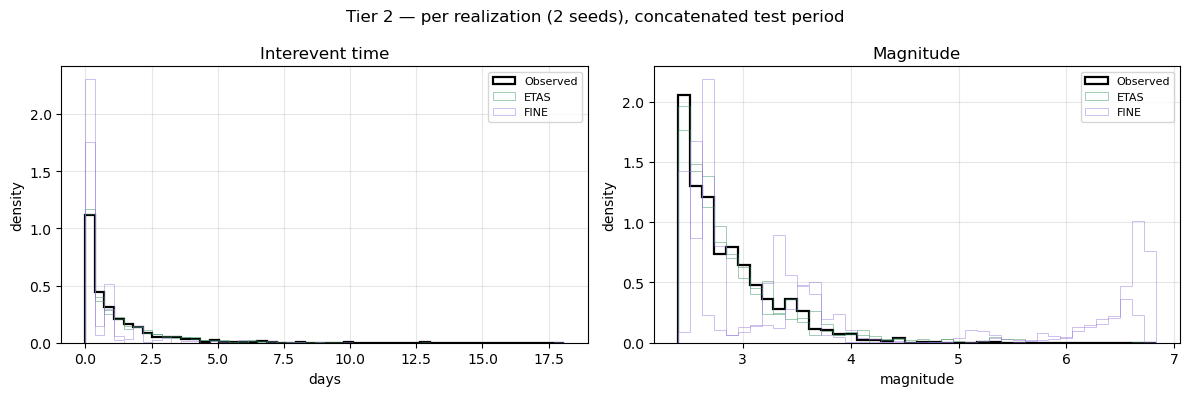

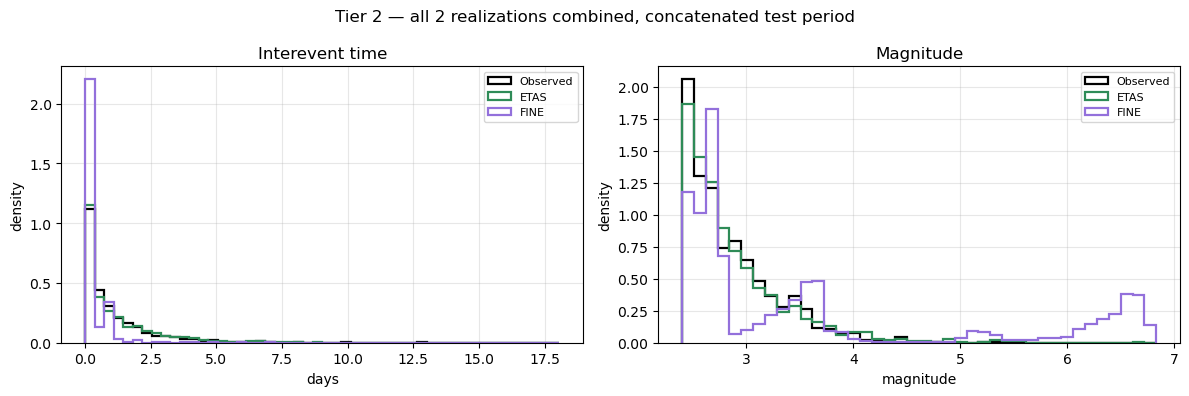

In [38]:
test_iet = utility_functions.interevent_times(observed_days)
test_mag = observed["magnitude"].to_numpy(dtype=float)
iet_by_method = {}
mag_by_method = {}
for method in METHODS:
    iets = []
    mags = []
    for frame in seed_frames[method].values():
        days = frame["time_days"].to_numpy(dtype=float) - origin_days
        iet = utility_functions.interevent_times(days)
        mag = frame["magnitude"].to_numpy(dtype=float)
        if iet.size:
            iets.append(iet)
        if mag.size:
            mags.append(mag)
    iet_by_method[method] = iets
    mag_by_method[method] = mags


def _edges(groups, observed_values, n_bins):
    parts = [observed_values, *[np.concatenate(group) for group in groups if group]]
    values = np.concatenate([part for part in parts if np.size(part)])
    return np.histogram_bin_edges(values[np.isfinite(values)], bins=n_bins)


iet_edges = _edges(iet_by_method.values(), test_iet, 50)
mag_edges = _edges(mag_by_method.values(), test_mag, 40)


def _hist_pair(pooled: bool, suptitle: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    pairs = (
        (axes[0], iet_by_method, test_iet, iet_edges, "Interevent time", "days"),
        (axes[1], mag_by_method, test_mag, mag_edges, "Magnitude", "magnitude"),
    )
    for ax, by_method, observed_values, edges, title, xlabel in pairs:
        if observed_values.size:
            ax.hist(
                observed_values, bins=edges, density=True, histtype="step",
                color="black", lw=1.6, label="Observed",
            )
        for method in METHODS:
            color = METHOD_COLORS.get(method)
            label = METHOD_LABELS.get(method, method)
            series = by_method[method]
            if not series:
                continue
            if pooled:
                ax.hist(
                    np.concatenate(series), bins=edges, density=True, histtype="step",
                    color=color, lw=1.6, label=label,
                )
            else:
                for index, values in enumerate(series):
                    ax.hist(
                        values, bins=edges, density=True, histtype="step",
                        color=color, lw=0.7, alpha=0.45, label=label if index == 0 else None,
                    )
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("density")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    show_fig(fig)


_hist_pair(False, f"Tier 2 — per realization ({len(SEEDS)} seeds), concatenated test period")
_hist_pair(True, f"Tier 2 — all {len(SEEDS)} realizations combined, concatenated test period")


## Spatial distribution

Same maps as the main rolling comparison, drawn from the cached event coordinates. The left column is one realization. The right column is the histogram of epicenters pooled over every seed. These are event locations, not the intensity.


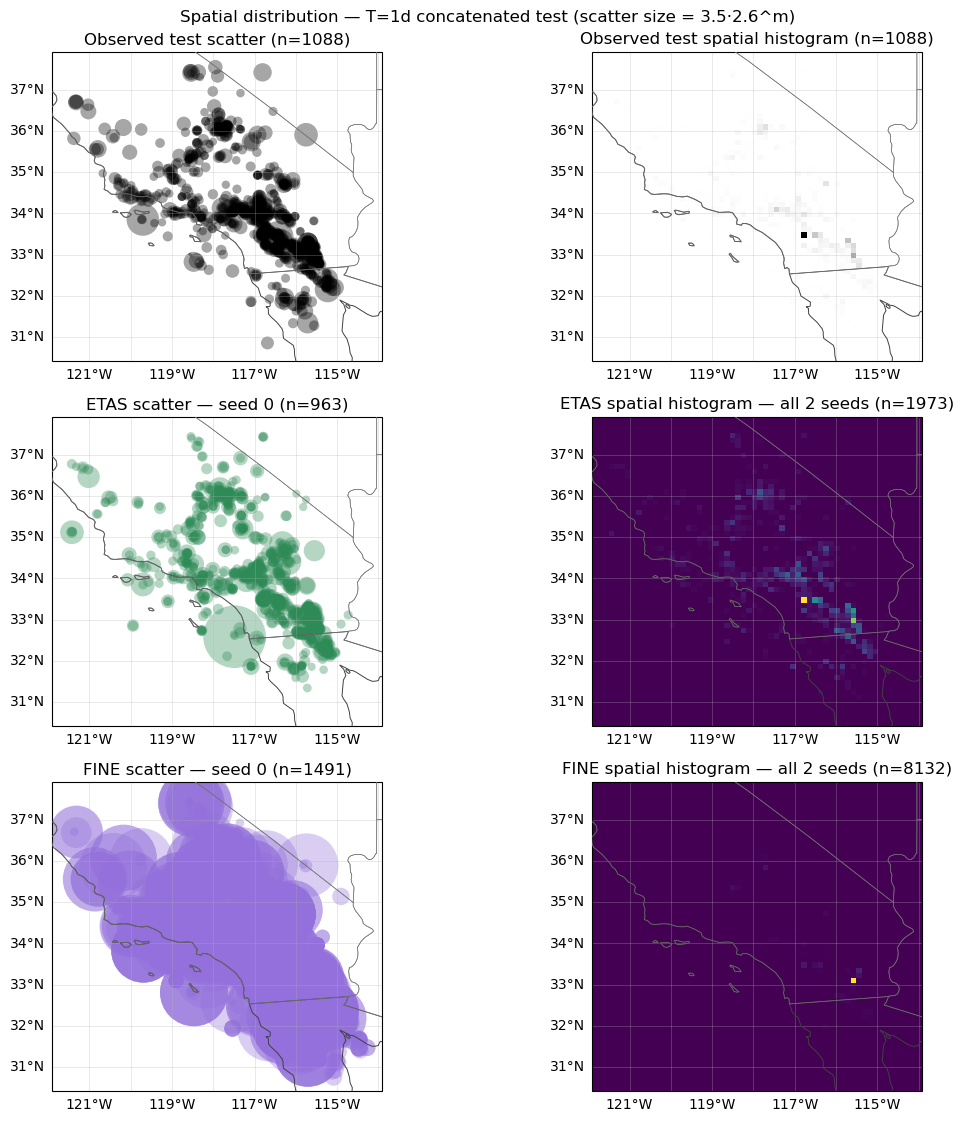

Map seed: **0**; pooled seeds: [0, 1]

In [39]:
_SPATIAL_BINS = 60
_MAG_SIZE_BASE = 2.6
_MAG_SIZE_SCALE = 3.5

try:
    from cartopy import crs as ccrs
    import cartopy.feature as cfeature
    _HAS_CARTOPY = True
except ImportError as exc:
    _HAS_CARTOPY = False
    display(Markdown(f"_Cartopy unavailable ({exc}); spatial maps without borders._"))


def _scatter_sizes(mags: np.ndarray) -> np.ndarray:
    return _MAG_SIZE_SCALE * (_MAG_SIZE_BASE ** np.asarray(mags, dtype=float))


def _add_map_borders(ax) -> None:
    if not _HAS_CARTOPY:
        return
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7, edgecolor="0.25", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.65, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.45, edgecolor="0.45", zorder=3)


def _plot_spatial_hist(ax, lon, lat, *, cmap: str, hist_range) -> None:
    H, xedges, yedges = np.histogram2d(
        lon, lat, bins=_SPATIAL_BINS, range=hist_range, density=True,
    )
    if _HAS_CARTOPY:
        ax.pcolormesh(
            xedges, yedges, H.T, cmap=cmap, shading="auto",
            transform=ccrs.PlateCarree(), zorder=1,
        )
    else:
        ax.pcolormesh(xedges, yedges, H.T, cmap=cmap, shading="auto", zorder=1)


obs_lon, obs_lat, obs_mag = store.observed_events()
method_seed_xyz = {method: store.events(method, MAP_SEED) for method in METHODS}
method_pool_xy = {}
for method in METHODS:
    lon_p, lat_p, _mag_p = store.pooled_events(method, SEEDS)
    method_pool_xy[method] = (lon_p, lat_p)

all_lon = [obs_lon] + [method_pool_xy[method][0] for method in METHODS]
all_lat = [obs_lat] + [method_pool_xy[method][1] for method in METHODS]
lon_cat = np.concatenate([a for a in all_lon if a.size]) if any(a.size for a in all_lon) else np.array([])
lat_cat = np.concatenate([a for a in all_lat if a.size]) if any(a.size for a in all_lat) else np.array([])
if lon_cat.size == 0:
    display(Markdown("_No lon/lat coordinates in the cache._"))
else:
    lon_pad = 0.05 * max(float(lon_cat.max() - lon_cat.min()), 0.5)
    lat_pad = 0.05 * max(float(lat_cat.max() - lat_cat.min()), 0.5)
    lon_range = (float(lon_cat.min()) - lon_pad, float(lon_cat.max()) + lon_pad)
    lat_range = (float(lat_cat.min()) - lat_pad, float(lat_cat.max()) + lat_pad)
    hist_range = [lon_range, lat_range]
    scatter_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    subplot_kw = {"projection": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(
        1 + len(METHODS), 2, figsize=(12, 3.8 * (1 + len(METHODS))),
        squeeze=False, subplot_kw=subplot_kw,
    )
    ax_s, ax_h = axes[0, 0], axes[0, 1]
    if obs_lon.size:
        ax_s.scatter(
            obs_lon, obs_lat, s=_scatter_sizes(obs_mag),
            c="black", alpha=0.35, linewidths=0, rasterized=True, zorder=2, **scatter_kw,
        )
        _plot_spatial_hist(ax_h, obs_lon, obs_lat, cmap="Greys", hist_range=hist_range)
    ax_s.set_title(f"Observed test scatter (n={obs_lon.size})")
    ax_h.set_title(f"Observed test spatial histogram (n={obs_lon.size})")
    for row_i, method in enumerate(METHODS, start=1):
        label = METHOD_LABELS.get(method, method)
        color = METHOD_COLORS.get(method) or f"C{row_i}"
        ax_s, ax_h = axes[row_i, 0], axes[row_i, 1]
        lon_s, lat_s, mag_s = method_seed_xyz[method]
        if lon_s.size:
            ax_s.scatter(
                lon_s, lat_s, s=_scatter_sizes(mag_s),
                c=color, alpha=0.35, linewidths=0, rasterized=True, zorder=2, **scatter_kw,
            )
        ax_s.set_title(f"{label} scatter — seed {MAP_SEED} (n={lon_s.size})")
        lon_p, lat_p = method_pool_xy[method]
        if lon_p.size:
            _plot_spatial_hist(ax_h, lon_p, lat_p, cmap="viridis", hist_range=hist_range)
        ax_h.set_title(f"{label} spatial histogram — all {len(SEEDS)} seeds (n={lon_p.size})")
    for ax in axes.ravel():
        _add_map_borders(ax)
        if _HAS_CARTOPY:
            ax.set_extent(
                [lon_range[0], lon_range[1], lat_range[0], lat_range[1]],
                crs=ccrs.PlateCarree(),
            )
            gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="0.7", alpha=0.5)
            gl.top_labels = False
            gl.right_labels = False
        else:
            ax.set_xlim(*lon_range)
            ax.set_ylim(*lat_range)
            ax.set_aspect("equal", adjustable="box")
            ax.grid(True, alpha=0.25)
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
    fig.suptitle(
        f"Spatial distribution — T={HORIZON_DAYS:g}d concatenated test "
        f"(scatter size = {_MAG_SIZE_SCALE}·{_MAG_SIZE_BASE}^m)",
        fontsize=12,
    )
    fig.tight_layout()
    show_fig(fig)
    display(Markdown(f"Map seed: **{MAP_SEED}**; pooled seeds: {SEEDS}"))


## Rate maps

One figure, five panels, one log color scale. Observed is the catalog count in each cell. The mean is the seed-averaged intensity added across the forecast windows. The realization is that integral for `MAP_SEED`. The number under each title is the sum over all cells: events in the catalog, or expected events for a rate map.


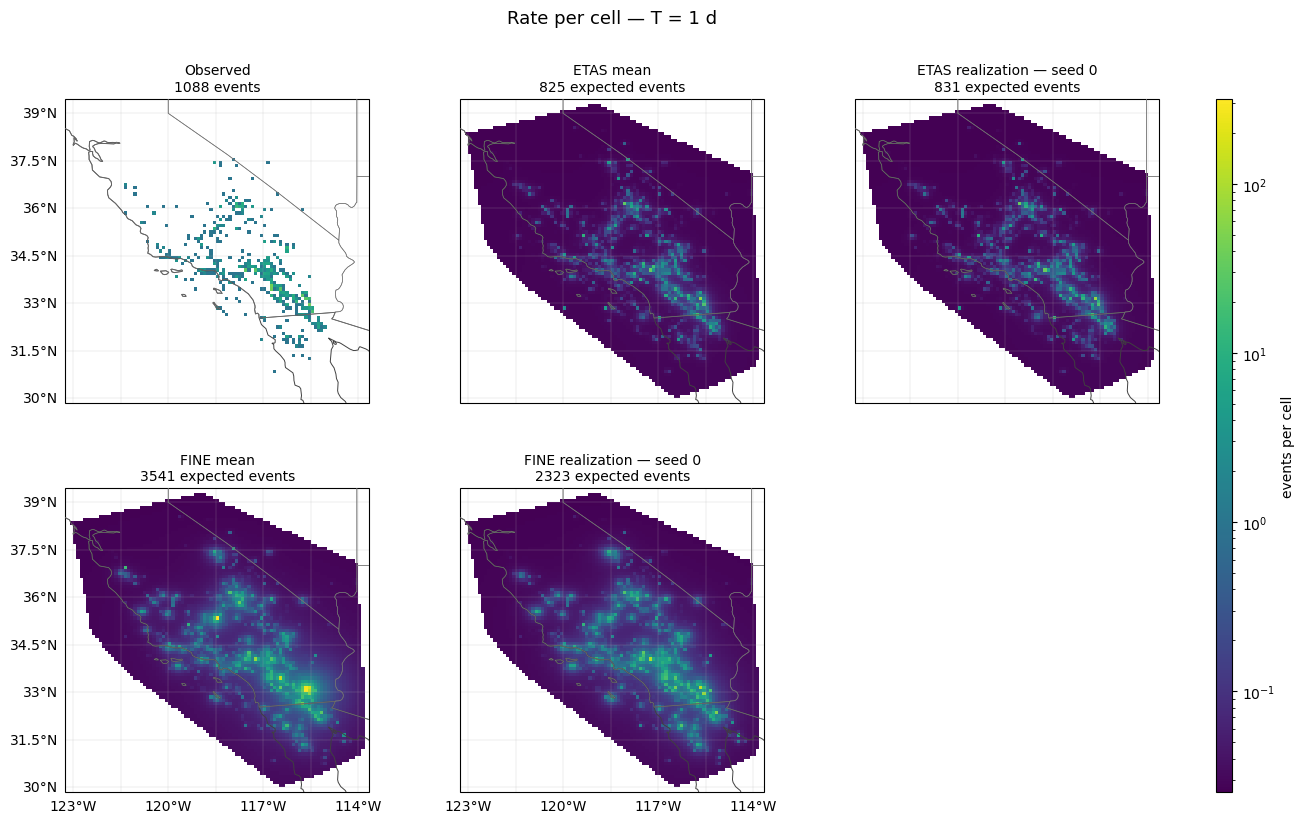

In [40]:
from matplotlib.colors import LogNorm

origins = store.origins
dh = store.dh
pad = 0.15
lon_edges = np.arange(origins[:, 0].min(), origins[:, 0].max() + dh * 1.01, dh)
lat_edges = np.arange(origins[:, 1].min(), origins[:, 1].max() + dh * 1.01, dh)
ix = np.rint((origins[:, 0] - lon_edges[0]) / dh).astype(int)
iy = np.rint((origins[:, 1] - lat_edges[0]) / dh).astype(int)
extent = [
    float(lon_edges[0]) - pad, float(lon_edges[-1]) + pad,
    float(lat_edges[0]) - pad, float(lat_edges[-1]) + pad,
]


def _cell_image(values: np.ndarray) -> np.ndarray:
    image = np.full((lat_edges.size - 1, lon_edges.size - 1), np.nan)
    image[iy, ix] = np.asarray(values, dtype=float)
    return np.ma.masked_where(~np.isfinite(image) | (image <= 0), image)


rate_panels = [
    ("Observed", store.observed_counts, "events"),
    (f"{METHOD_LABELS.get('etas', 'etas')} mean", store.mean_spatial("etas"), "expected events"),
    (f"{METHOD_LABELS.get('etas', 'etas')} realization — seed {MAP_SEED}", store.seed_spatial("etas", MAP_SEED), "expected events"),
    (f"{METHOD_LABELS.get('FINE', 'FINE')} mean", store.mean_spatial("FINE"), "expected events"),
    (f"{METHOD_LABELS.get('FINE', 'FINE')} realization — seed {MAP_SEED}", store.seed_spatial("FINE", MAP_SEED), "expected events"),
]
positive = np.concatenate([
    values[np.isfinite(values) & (values > 0)] for _title, values, _kind in rate_panels
])
shared = LogNorm(vmin=float(positive.min()), vmax=float(positive.max()))
fig = plt.figure(figsize=(15.5, 9.0))
grid = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.045], wspace=0.08, hspace=0.28)
flat = []
for panel in range(5):
    row, col = divmod(panel, 3)
    if _HAS_CARTOPY:
        flat.append(fig.add_subplot(grid[row, col], projection=ccrs.PlateCarree()))
    else:
        flat.append(fig.add_subplot(grid[row, col]))
cax = fig.add_subplot(grid[:, 3])
mesh = None
for panel, (title, values, kind) in enumerate(rate_panels):
    ax = flat[panel]
    row, col = divmod(panel, 3)
    image = _cell_image(values)
    if _HAS_CARTOPY:
        mesh = ax.pcolormesh(
            lon_edges, lat_edges, image, cmap="viridis", norm=shared, shading="flat",
            transform=ccrs.PlateCarree(), zorder=1,
        )
        _add_map_borders(ax)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.7", alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = col == 0
        gl.bottom_labels = row == 1
    else:
        mesh = ax.pcolormesh(lon_edges, lat_edges, image, cmap="viridis", norm=shared, shading="flat")
        ax.set_aspect("equal", adjustable="box")
    total = float(np.nansum(values))
    ax.set_title(f"{title}\n{total:.0f} {kind}", fontsize=10)
fig.colorbar(mesh, cax=cax, label="events per cell")
fig.suptitle(f"Rate per cell — T = {HORIZON_DAYS:g} d", fontsize=13, y=0.98)
show_fig(fig)


## CSEP catalog tests — concatenated trajectory

The first set scores the simulated catalogs. The second set keeps those catalogs for the number test and scores L, M, S, and the Poisson L-test on the summed intensity grid.


Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 988.0 events after removing 100.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 988.0 events after removing 100.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1006.0 events after removing 82.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1006.0 events after removing 82.0 events.


### Concatenated catalogs

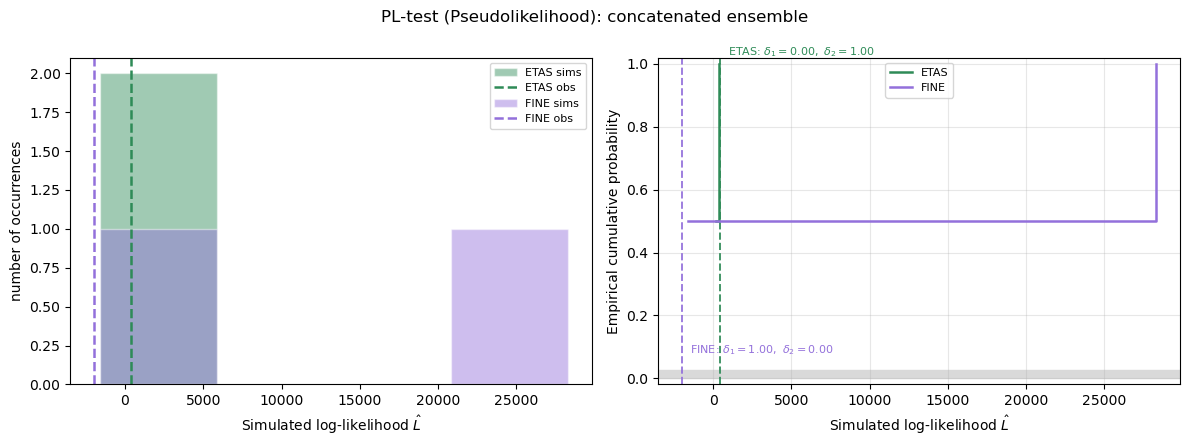

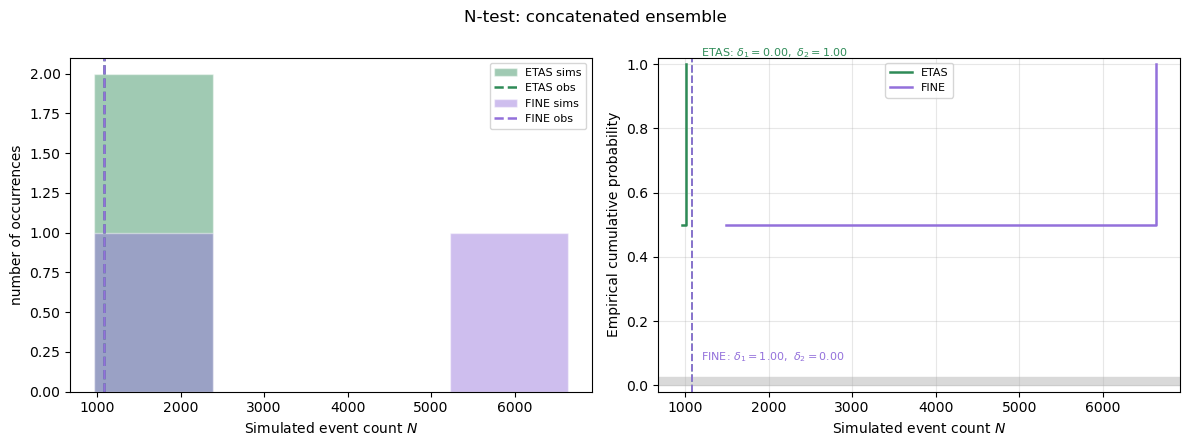

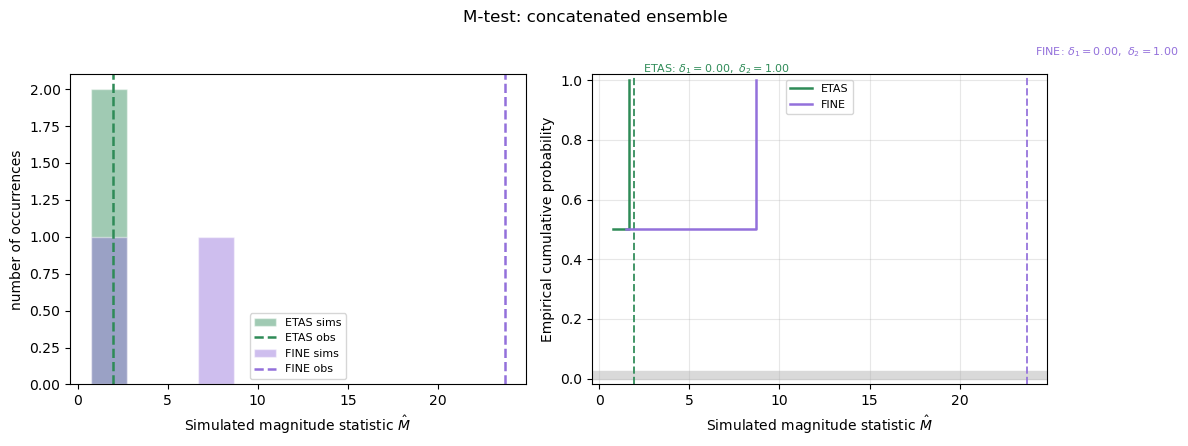

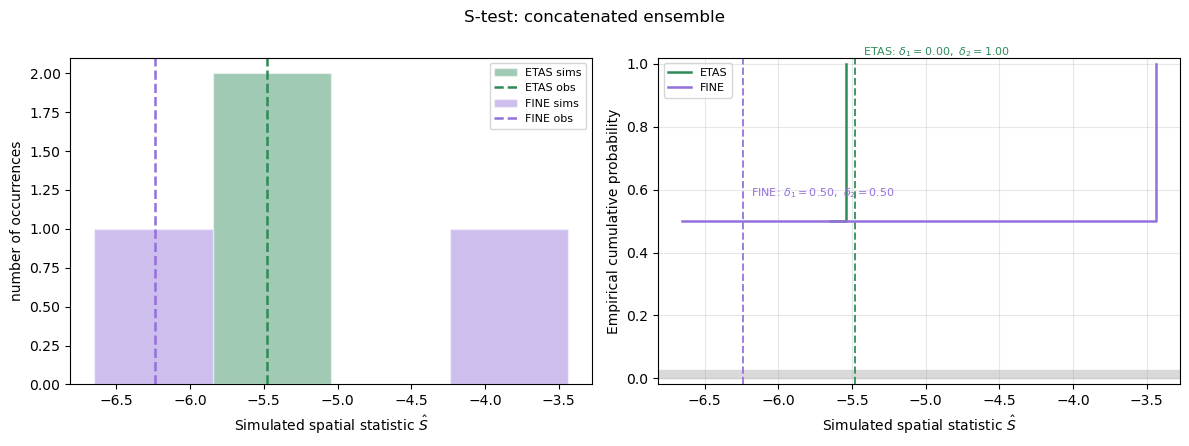

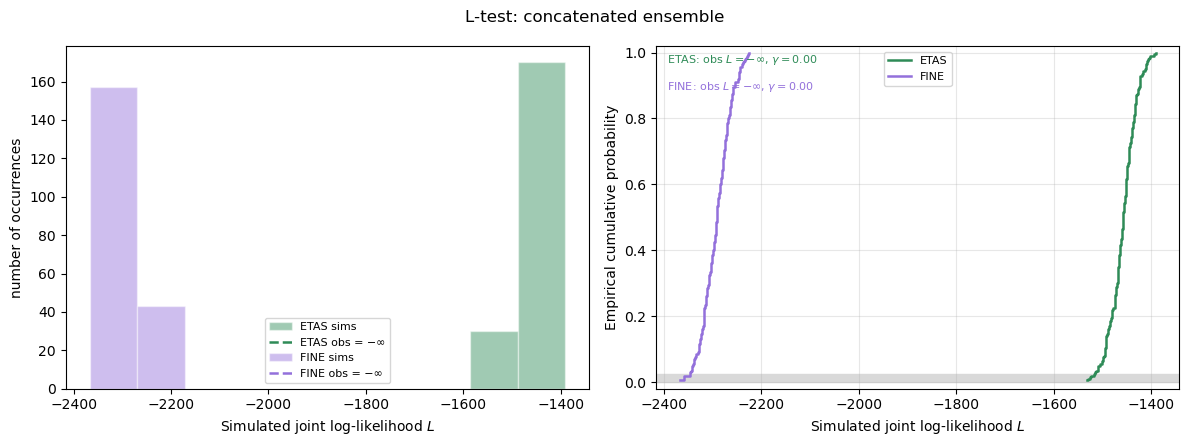

,method,ASS,area_below_diagonal,n_bins,n_target_bins
0,ETAS,0.851528,0.351528,5881,362.0
1,FINE,0.869459,0.369459,5881,362.0


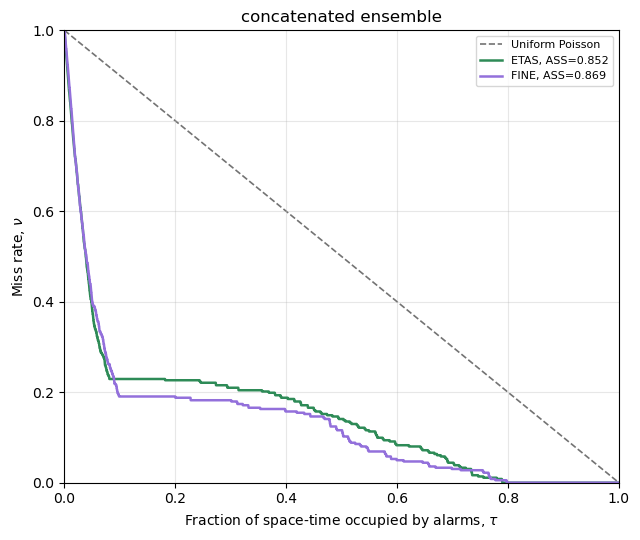

### Averaged intensity

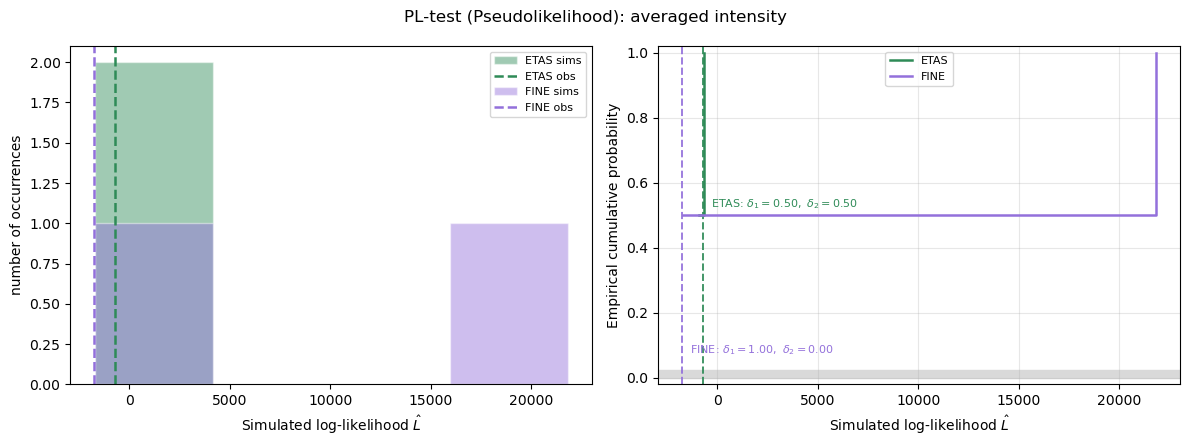

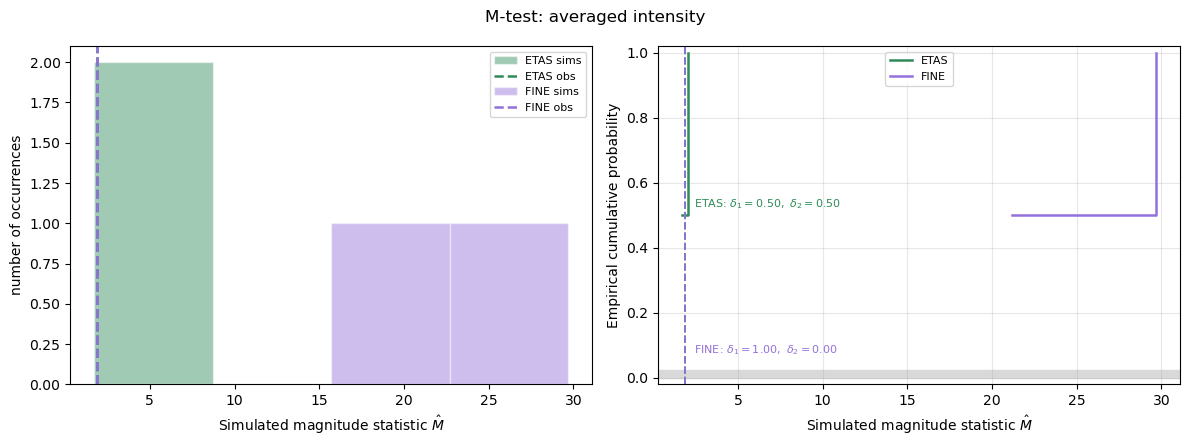

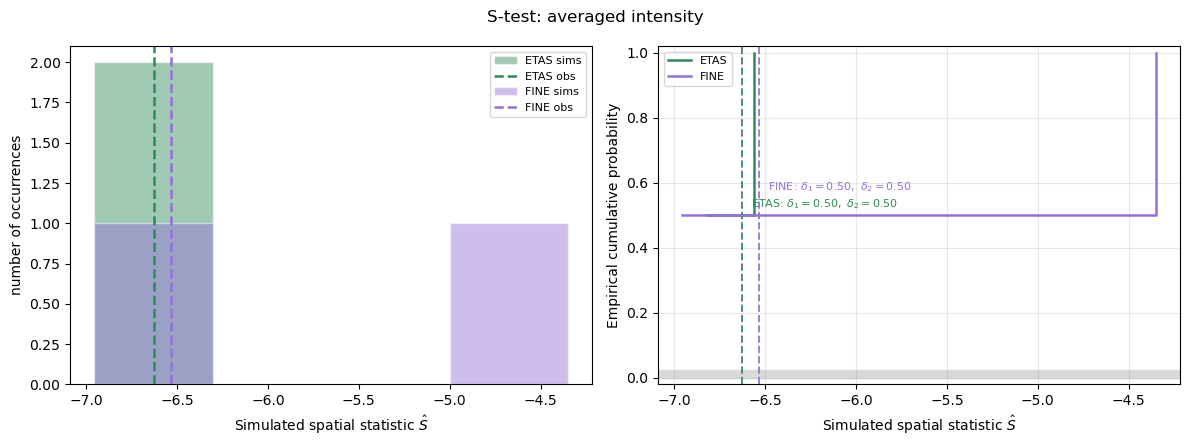

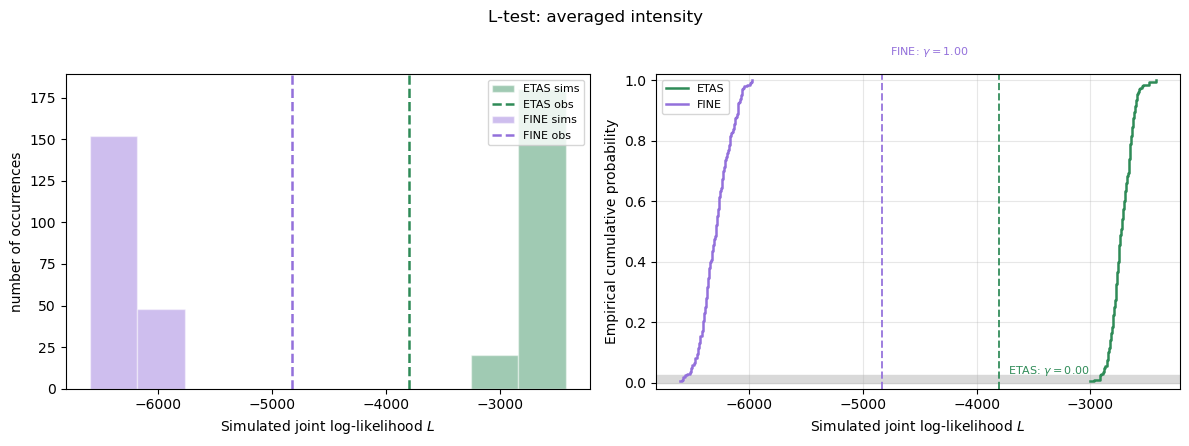

In [41]:
region, study_poly, fit = store.forecast_region()
m_ref = float(fit["m_ref"])
span_start = windows["forecast_start"].min().to_pydatetime()
span_end = windows["forecast_end"].max().to_pydatetime()


def _csep_frame(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["time"] = pd.Timestamp("1970-01-01") + pd.to_timedelta(out["time_days"], unit="D")
    return out


def _forecasts():
    built = {}
    for method in METHODS:
        catalogs = [_csep_frame(seed_frames[method][seed]) for seed in SEEDS]
        built[method] = csep_utils.build_catalog_forecast_from_dataframes(
            catalogs,
            name=METHOD_LABELS.get(method, method),
            region=region,
            start_time=span_start,
            end_time=span_end,
            m_ref=m_ref,
            study_poly=study_poly,
        )
    return built


observed_csep = csep_utils.dataframe_to_csep_catalog(
    _csep_frame(observed), catalog_id=0, region=region,
)
catalog_forecasts = _forecasts()
catalog_scores = {
    method: csep_utils.run_csep_catalog_tests(
        forecast, observed_csep, include_l_test=True, l_test_simulations=200, l_test_seed=0,
    )
    for method, forecast in catalog_forecasts.items()
}
display(Markdown("### Concatenated catalogs"))
for fig in csep_utils.plot_csep_metric_overlays(
    catalog_scores, title="concatenated ensemble", colors=METHOD_COLORS, labels=METHOD_LABELS,
):
    show_fig(fig)
molchan_table, molchan_fig = csep_utils.molchan_comparison(
    catalog_forecasts, observed_csep, labels=METHOD_LABELS, colors=METHOD_COLORS,
    title="concatenated ensemble",
)
display(molchan_table)
if molchan_fig is not None:
    show_fig(molchan_fig)

rate_grids = store.mean_rate_grid()
intensity_scores = {}
for method, forecast in catalog_forecasts.items():
    previous_rates = forecast.expected_rates
    forecast.expected_rates = csep_utils.gridded_forecast_from_rates(
        rate_grids[method],
        region,
        forecast.start_time,
        forecast.end_time,
        f"{METHOD_LABELS.get(method, method)} intensity",
    )
    try:
        intensity_scores[method] = csep_utils.run_csep_catalog_tests(
            forecast, observed_csep, include_l_test=True, l_test_simulations=200, l_test_seed=1,
        )
    finally:
        forecast.expected_rates = previous_rates
display(Markdown("### Averaged intensity"))
for fig in csep_utils.plot_csep_metric_overlays(
    intensity_scores,
    title="averaged intensity",
    colors=METHOD_COLORS,
    labels=METHOD_LABELS,
    test_names=("PL-test (Pseudolikelihood)", "M-test", "S-test", "L-test"),
):
    show_fig(fig)
